# v12_vs_v15.py

Auto-generated from `notebooks/v12_vs_v15.py`.

                  v12 (cap=160)  v15 (v12 + gate)
final_pnl           460722.0000       458648.0000
sharpe_ratio             5.2005            5.4964
max_drawdown_abs     60493.0000        60493.0000
max_drawdown_pct        20.1129           20.1129
calmar_ratio             7.6161            7.5818


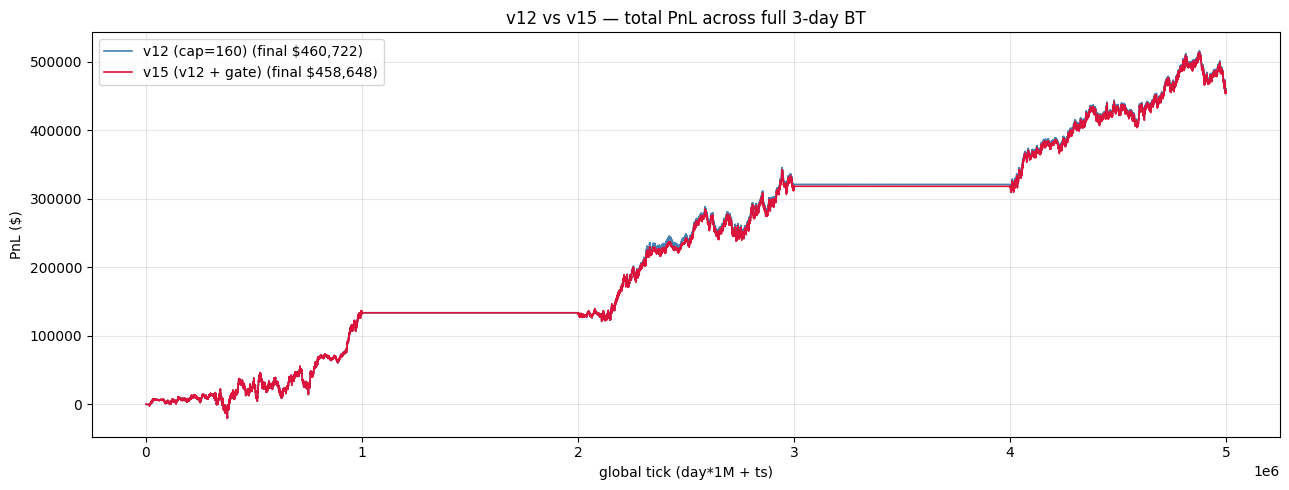

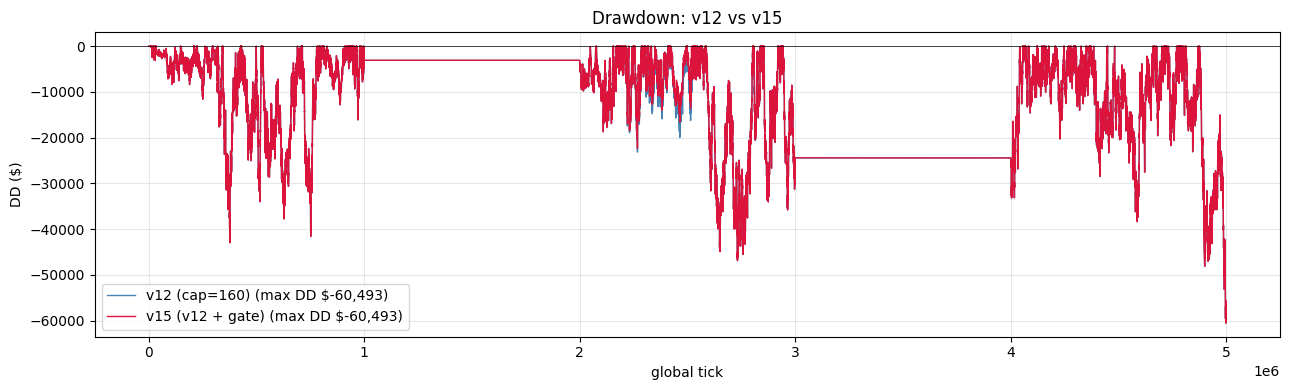

                     v12 (cap=160)  v15 (v12 + gate)
product                                             
HYDROGEL_PACK             232206.0          232206.0
VELVETFRUIT_EXTRACT       159619.0          159619.0
VEV_5000                  150417.5          151164.5
VEV_5100                  158277.5          157897.5
VEV_5200                  131761.0          130793.0
VEV_5300                   83304.0           79106.0


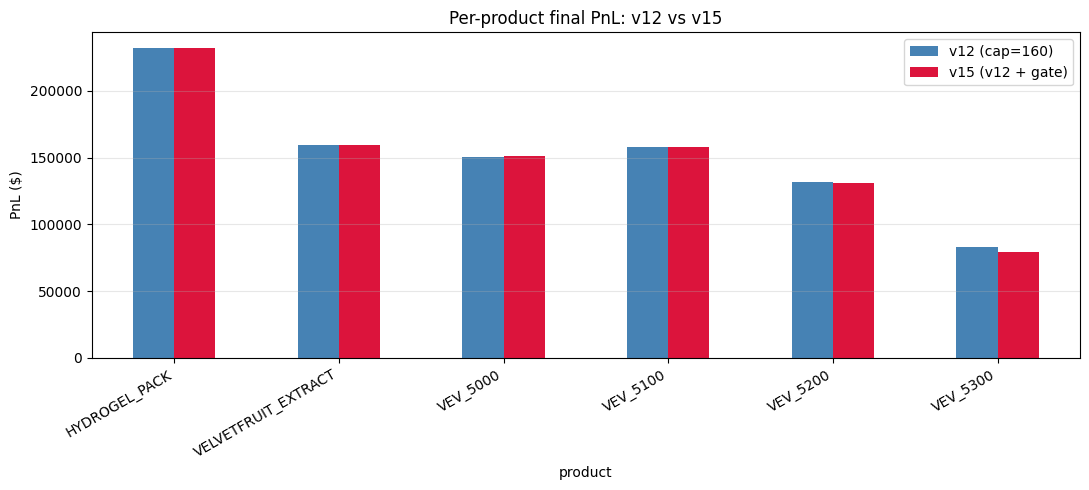

In [1]:
# %% [markdown]
# # v12 vs v15 — does the insider-flow gate actually help?
# v15 = v12 (cap=160) + v11's InformedFlowTracker. Same trades except the
# gate blocks adding voucher inventory when recent VFE aggressor flow
# predicts adverse drift.

# %%
import io, subprocess, re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TRADERS = {
    "v12 (cap=160)": ROOT / "docs/round_3/strategies/snapshots/v12_trader.py",
    "v15 (v12 + gate)": ROOT / "docs/round_3/strategies/snapshots/v15_trader.py",
}

# %%
def run_bt(trader_path):
    out = subprocess.run(
        [str(ROOT / "venv/bin/prosperity4btest"), "cli", str(trader_path), "3",
         "--merge-pnl", "--no-progress"],
        capture_output=True, text=True, cwd=ROOT,
    ).stdout
    log_match = re.search(r"Successfully saved backtest results to (\S+\.log)", out)
    bt_log = ROOT / log_match.group(1)
    text = bt_log.read_text()
    csv_block = text.split("Activities log:")[1].split("Trade History:")[0].strip()
    df = pd.read_csv(io.StringIO(csv_block), sep=";")
    metrics = {}
    for k in ("final_pnl", "sharpe_ratio", "max_drawdown_abs", "max_drawdown_pct", "calmar_ratio"):
        m = re.search(rf"{k}: ([\d,\.]+)", out)
        if m:
            metrics[k] = float(m.group(1).replace(",", ""))
    return df, metrics

results = {name: run_bt(p) for name, p in TRADERS.items()}

# %%
# --- Metrics table ---
mtable = pd.DataFrame({n: r[1] for n, r in results.items()})
print(mtable.to_string())

# %%
# --- Total PnL curves ---
fig, ax = plt.subplots(figsize=(13, 5))
colors = {"v12 (cap=160)": "steelblue", "v15 (v12 + gate)": "crimson"}
for name, (df, m) in results.items():
    df = df.copy()
    df["global_t"] = df["day"] * 1_000_000 + df["timestamp"]
    total = df.groupby("global_t")["profit_and_loss"].sum()
    ax.plot(total.index, total.values, label=f"{name} (final ${m['final_pnl']:,.0f})",
            lw=1.2, color=colors[name])
ax.set_title("v12 vs v15 — total PnL across full 3-day BT")
ax.set_xlabel("global tick (day*1M + ts)")
ax.set_ylabel("PnL ($)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# %%
# --- Drawdown comparison ---
fig, ax = plt.subplots(figsize=(13, 4))
for name, (df, m) in results.items():
    df = df.copy()
    df["global_t"] = df["day"] * 1_000_000 + df["timestamp"]
    total = df.groupby("global_t")["profit_and_loss"].sum()
    dd = total - total.cummax()
    ax.plot(dd.index, dd.values, lw=1, label=f"{name} (max DD ${dd.min():,.0f})",
            color=colors[name])
ax.set_title("Drawdown: v12 vs v15")
ax.set_xlabel("global tick"); ax.set_ylabel("DD ($)")
ax.legend(); ax.grid(alpha=0.3); ax.axhline(0, color="black", lw=0.5)
plt.tight_layout()
plt.show()

# %%
# --- Per-product final PnL ---
def per_product_final(df):
    last_per_day = df.groupby("day")["timestamp"].max().reset_index()
    finals = df.merge(last_per_day, on=["day", "timestamp"])
    return finals.groupby("product")["profit_and_loss"].sum().sort_values(ascending=False)

bar_df = pd.DataFrame({n: per_product_final(r[0]) for n, r in results.items()})
traded = ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT", "VEV_5000", "VEV_5100", "VEV_5200", "VEV_5300"]
bar_df = bar_df.reindex(traded)
print(bar_df)
ax = bar_df.plot.bar(figsize=(11, 5), color=[colors[n] for n in bar_df.columns])
ax.set_title("Per-product final PnL: v12 vs v15")
ax.set_ylabel("PnL ($)"); ax.grid(alpha=0.3, axis="y"); ax.axhline(0, color="black", lw=0.5)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# %% [markdown]
# ## How to read this
# - If v15 curve hugs v12 closely with slightly smoother shape → gate
#   helps a tiny bit. Diff in DD and Sharpe is the real signal.
# - If per-product PnL is identical except smaller voucher PnL → gate is
#   working but skipping profitable trades.
# - Gate barely fires on day 2 first 1000 ticks (verified — portal slice
#   was byte-identical). Bigger effect on days 0/1 if any.
